In [78]:
import pandas as pd
import statsmodels.api as sm 
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

df = pd.read_csv('/Users/aeason/Desktop/Python files/SAC Coding Meetings/wc_data.csv')

In [79]:
train = df[df['Year'] < 2022]
test = df[df['Year'] == 2022]

In [80]:
df.columns

Index(['home_team', 'away_team', 'home_score', 'home_xg', 'home_penalty',
       'away_score', 'away_xg', 'away_penalty', 'home_manager', 'home_captain',
       'away_manager', 'away_captain', 'Attendance', 'Venue', 'Officials',
       'Round', 'Date', 'Score', 'Referee', 'Notes', 'Host', 'Year',
       'home_goal', 'away_goal', 'home_goal_long', 'away_goal_long',
       'home_own_goal', 'away_own_goal', 'home_penalty_goal',
       'away_penalty_goal', 'home_penalty_miss_long', 'away_penalty_miss_long',
       'home_penalty_shootout_goal_long', 'away_penalty_shootout_goal_long',
       'home_penalty_shootout_miss_long', 'away_penalty_shootout_miss_long',
       'home_red_card', 'away_red_card', 'home_yellow_red_card',
       'away_yellow_red_card', 'home_yellow_card_long',
       'away_yellow_card_long', 'home_substitute_in_long',
       'away_substitute_in_long', 'home_win'],
      dtype='object')

In [81]:
X = train[['home_xg', 'away_xg']]
y = train['home_win'] 

In [82]:
vif = pd.DataFrame()
vif['feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

   feature       VIF
0  home_xg  1.907497
1  away_xg  1.907497


In [83]:
X = X.astype(float)

X = sm.add_constant(X)
model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.672103
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               home_win   No. Observations:                  900
Model:                          Logit   Df Residuals:                      897
Method:                           MLE   Df Model:                            2
Date:                Thu, 09 Jul 2026   Pseudo R-squ.:                 0.02054
Time:                        12:44:51   Log-Likelihood:                -604.89
converged:                       True   LL-Null:                       -617.58
Covariance Type:            nonrobust   LLR p-value:                 3.102e-06
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2805      0.070      4.026      0.000       0.144       0.417
home_xg        0.7670      0.

In [84]:
X_test = test[['home_xg', 'away_xg']]
X_test = X_test.astype(float)

X_test = sm.add_constant(X_test)

test_probs = model.predict(X_test)

test_preds = (test_probs >= 0.5).astype(int)

y_test = test['home_win']

print(f"Accuracy: {accuracy_score(y_test, test_preds):.2%}\n")
print(classification_report(y_test, test_preds))

Accuracy: 67.19%

              precision    recall  f1-score   support

           0       0.65      0.86      0.74        35
           1       0.72      0.45      0.55        29

    accuracy                           0.67        64
   macro avg       0.69      0.65      0.65        64
weighted avg       0.68      0.67      0.66        64



In [85]:
auc = roc_auc_score(y_test, test_probs)
print(f"AUC: {auc:.3f}")

AUC: 0.744


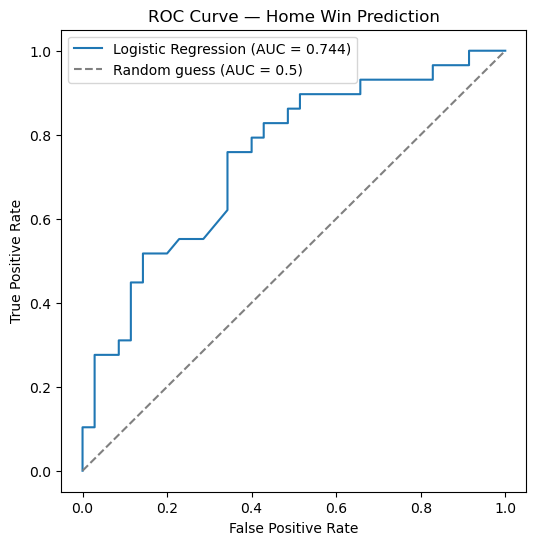

In [86]:
fpr, tpr, thresholds = roc_curve(y_test, test_probs)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Home Win Prediction')
plt.legend()
plt.show()